Now that we have shown that the k-fold models generalize better to the test data than a random baseline, we will generate a new model with the best hyperparameters identified, but trained on the training + validation data. This is simply to have one coherent model for additional downstream assessments. It also should give the model better power.

In [1]:
import os

import pandas as pd
import scanpy as sc

import torch
import torch.nn as nn
import numpy as np
from geomloss import SamplesLoss

import matplotlib.pyplot as plt
import seaborn as sns


import sys
sys.path.insert(1, '../.')
from Kang_utils import get_best_hyperparams


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.model.scl_dev import SignalingModel
from scLEMBAS.model.train import TrainSC


In [3]:
author = 'Kang'
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')

In [4]:
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

# ensures correct order of test data
# note, this already saved in order, matching the mod.y_out columns
tf_adata = tf_adata[:, sorted(tf_adata.var_names)] 

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [6]:
test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()
train_cells = [barcode for barcode in tf_adata.obs_names if barcode not in test_cells]


In [7]:
res = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_k_fold_validation_results.csv'), index_col = 0)
best_emd_mean, best_hyperparams, best_emd = get_best_hyperparams(res)

trainers_best = {k: io.read_pickled_object(os.path.join(models_path, 'Kang_best_trainer_' + str(k) + '.pickle')) for k in range(best_emd.shape[0])}


Select a hyper-parameter tuning model that uses the most common KL regularization value:

In [8]:
kl_reg = best_emd.KL_regularization.value_counts().idxmax()

kl_og = np.nan
for k, trainer_k in trainers_best.items():
    if kl_og != kl_reg:
        print(k)
        kl_og = trainer_k.hyper_params['vae_scaling_KL']
        mod_actual = trainer_k.mod
    else:
        break

0


In [9]:
bionet_params_dev = mod_actual.signaling_network.bionet_params.copy()
bionet_params_dev['bias_tot_scaler'] = 2
bionet_params_dev['signaling_weights_scaler'] = 10

Build and train the full model:

In [ ]:
mod_full = SignalingModel(net = sn_ppis,
                     X_in = mod_actual.X_in.copy(),
                     y_out = mod_actual.y_out.copy(), 
                     expr = mod_actual.expr.copy(), 
                     covariates = mod_actual.signaling_network.covariates.copy(),
                     categorical_covariate_keys = mod_actual.signaling_network.covariates.columns.tolist(),
                     projection_amplitude_in = mod_actual.input_layer.projection_amplitude, 
                     projection_amplitude_out = mod_actual.projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params_dev, 
                     dtype = torch.float32, device = device, seed = seed)
mod_full.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod_full.signaling_network.prescale_weights(target_radius = mod_actual.signaling_network.bionet_params['spectral_target']) # spectral radius

hyper_params = trainer_k.hyper_params
hyper_params['validation_batch_size'] = np.nan
hyper_params['test_batch_size'] = len(test_cells)

trainer = TrainSC(mod = mod_full,
                  prediction_optimizer = torch.optim.Adam,
                  prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
                  discriminator_params = trainer_k.discriminator['params'].copy(),
                  hyper_params = hyper_params.copy(),
              train_split = {'train': train_cells, 'test': test_cells, 'validation': None},
              train_seed = seed,
              track_test = False,
              track_validation = False)

mod_full = trainer.train_model(verbose = False)
io.write_pickled_object(trainer, os.path.join(data_path, 'trash', 'Kang_fullbest_trainer.pickle'))


Let's also train the same model, but without adverserial training. Specifically, we set the penalization of the discriminator loss to 100-fold less than the minimum value used during adverserial training:

In [ ]:
# noadverserial_params = trainer_k.discriminator['params'].copy()
# noadverserial_params['discriminator_penalty_weight'] = min(noadverserial_params['discriminator_penalty_weight'])

# mod_no_adverserial = SignalingModel(net = sn_ppis,
#                      X_in = mod_actual.X_in.copy(),
#                      y_out = mod_actual.y_out.copy(), 
#                      expr = mod_actual.expr.copy(), 
#                      covariates = mod_actual.signaling_network.covariates.copy(),
#                      categorical_covariate_keys = mod_actual.signaling_network.covariates.columns.tolist(),
#                      projection_amplitude_in = mod_actual.input_layer.projection_amplitude, 
#                      projection_amplitude_out = mod_actual.projection_amplitude_out,
#                      weight_label = weight_label, source_label = source_label, target_label = target_label,
#                      bionet_params = mod_actual.signaling_network.bionet_params.copy(), 
#                      dtype = torch.float32, device = device, seed = seed)
# mod_no_adverserial.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
# mod_no_adverserial.signaling_network.prescale_weights(target_radius = mod_actual.signaling_network.bionet_params['spectral_target']) # spectral radius

# hyper_params = trainer_k.hyper_params
# hyper_params['validation_batch_size'] = np.nan
# hyper_params['test_batch_size'] = len(test_cells)

# trainer = TrainSC(mod = mod_no_adverserial,
#                   prediction_optimizer = torch.optim.Adam,
#                   prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
#                   discriminator_params = noadverserial_params,
#                   hyper_params = hyper_params.copy(),
#               train_split = {'train': train_cells, 'test': test_cells, 'validation': None},
#               train_seed = seed,
#               track_test = False,
#               track_validation = False)

# mod_no_adverserial = trainer.train_model(verbose = False)
# io.write_pickled_object(trainer, os.path.join(data_path, 'trash', 'Kang_no_adverserial_trainer.pickle'))


Let's see what the learning rate and MOA violations look like across epochs:

In [10]:
trainer = io.read_pickled_object(os.path.join(data_path, 'trash', 'Kang_fullbest_trainer.pickle'))

In [11]:
train_stats_df = trainer.stats['train'].copy()

train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() # delete this

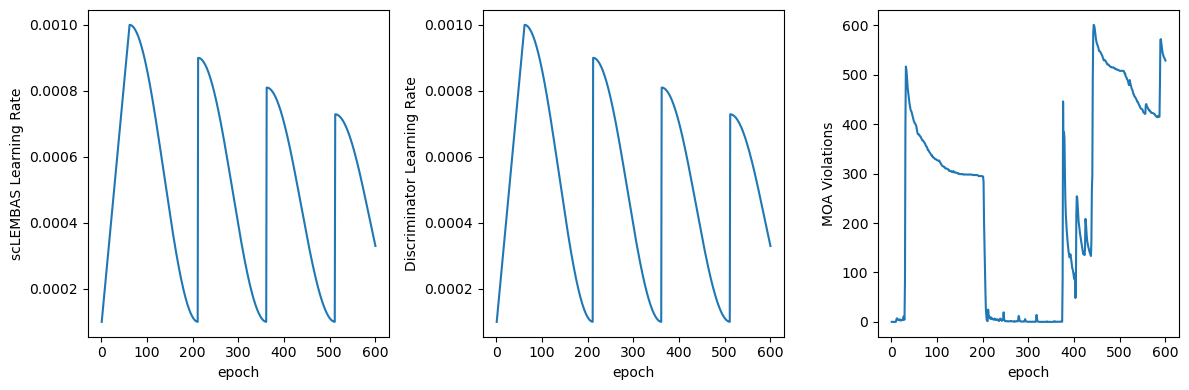

In [12]:
fig, ax = plt.subplots(ncols = 3, figsize = (12, 4))

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'learning_rate', ax = ax[0])
ax[0].set_ylabel('scLEMBAS Learning Rate')

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'discriminator_learning_rate', ax = ax[1])
ax[1].set_ylabel('Discriminator Learning Rate')

sns.lineplot(data = train_stats_df, x = 'epoch', y = 'n_moa_violations', ax = ax[2])
ax[2].set_ylabel('MOA Violations')

fig.tight_layout()


Let's also see what the loss looks like across epochs:

/tmp/ipykernel_3192205/3263610623.py:32: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax)


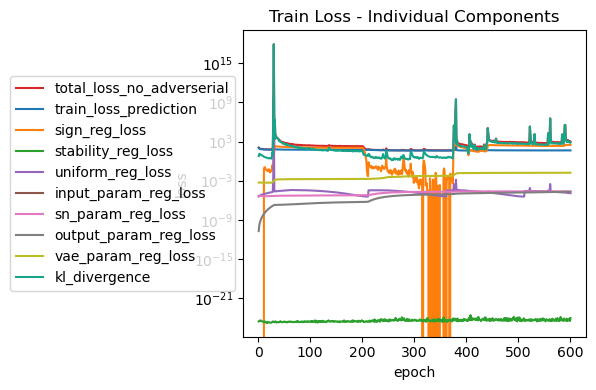

In [13]:
fig, ax = plt.subplots(ncols = 1, figsize = (8, 4))

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)


# # plot 1: no adverserial
loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_loss', 'output_param_reg_loss', 'vae_param_reg_loss', 'kl_divergence']


viz_df = train_stats_df[['epoch'] + loss_cols_main].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial'] + loss_cols_main)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax)
# ax.set_yscale('log')
ax.legend(loc='center left', bbox_to_anchor=(-0.7, 0.5))
ax.set_title('Train Loss - Individual Components')
ax.set_yscale('log')

fig.tight_layout()


# Bias adverserial

In [22]:
from Kang_utils import get_prediction, adata_dimviz_bias
from scLEMBAS.preprocess import embed_tf_activity

In [15]:
mod = trainer.mod


/tmp/ipykernel_3192205/2909672884.py:34: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
/tmp/ipykernel_3192205/2909672884.py:60: UserWarning: The palette list has more values (12) than needed (3), which may not be intended.
  sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[2])


''

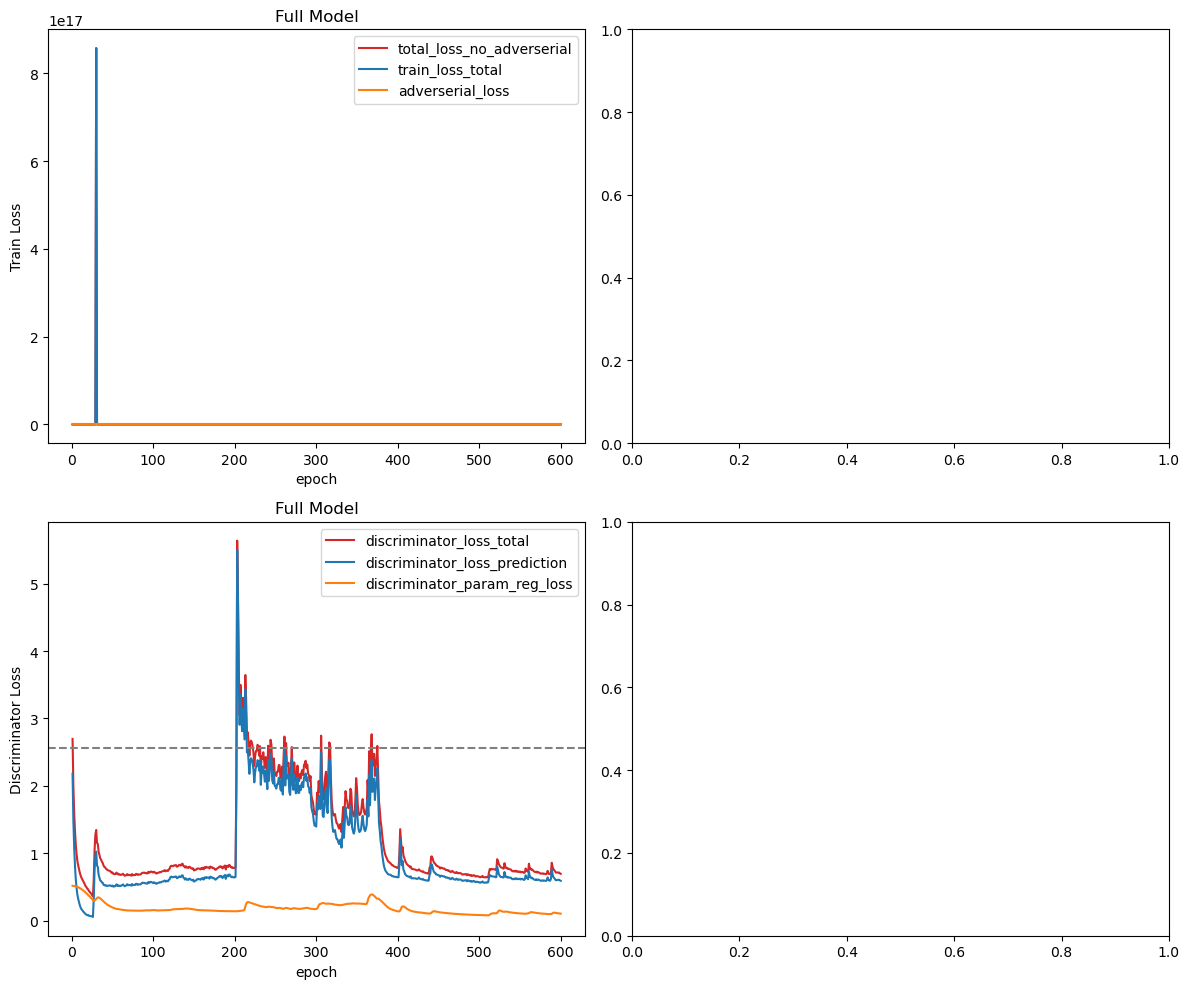

In [16]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,10))
ax = ax.flatten()

colors = [
    "#d62728",  # Red
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Olive
    "#17a589",  #  Teal 
    "#6baed6",  # light blue
    "#ff9896"   # Light red
]
palette = sns.color_palette(colors)


# Plot 1: full model, adverserial loss
loss_cols_main = [
       'train_loss_prediction', 'sign_reg_loss',
       'stability_reg_loss', 'uniform_reg_loss', 'input_param_reg_loss',
       'sn_param_reg_loss', 'output_param_reg_loss', 'vae_param_reg_loss', 'kl_divergence']
loss_cols = ['train_loss_total'] + loss_cols_main + ['adverserial_loss']

viz_df = train_stats_df[['epoch'] + loss_cols].copy()
viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
viz_df.drop(columns = loss_cols_main, inplace = True)
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[0])
ax[0].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
ax[0].set_ylabel('Train Loss')
ax[0].set_title('Full Model')

# # Plot 2: model no adverserial, adverserial loss
# viz_df = train_stats_df_na[['epoch'] + loss_cols].copy()
# viz_df['total_loss_no_adverserial'] = viz_df[loss_cols_main].sum(axis = 1)
# viz_df.drop(columns = loss_cols_main, inplace = True)
# viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
# viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=['total_loss_no_adverserial', 'train_loss_total', 'adverserial_loss'])

# sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette=palette, ax = ax[1])
# ax[1].legend(loc='best')#, bbox_to_anchor=(1.05, 0.5))
# ax[1].set_ylabel('Train Loss')
# ax[1].set_title('No Adverserial Model')


# Plot 3: full model, discriminator loss
loss_cols_disc = ['discriminator_loss_total',
       'discriminator_loss_prediction', 'discriminator_param_reg_loss']

viz_df = train_stats_df[['epoch'] + loss_cols_disc].copy()
viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[2])
n_cat = trainer.discriminator['discriminators']['seurat_annotations'].classifier[1].fc_layers[0][0].out_features
ax[2].axhline(y=np.log(n_cat), color='gray', linestyle='--')

ax[2].legend(loc='best')
ax[2].set_ylabel('Discriminator Loss')
ax[2].set_title('Full Model')

# # Plot 4: model no adverserial, discriminator loss
# viz_df = train_stats_df_na[['epoch'] + loss_cols_disc].copy()
# viz_df = viz_df.melt(id_vars = ['epoch'], var_name = 'loss_type', value_name = 'loss')
# viz_df.loss_type = pd.Categorical(viz_df.loss_type, ordered = True, categories=loss_cols_disc)

# sns.lineplot(data = viz_df, x = 'epoch', y = 'loss', hue='loss_type', palette = palette, ax = ax[3])
# n_cat = trainer.discriminator['discriminators']['seurat_annotations'].classifier[1].fc_layers[0][0].out_features
# ax[3].axhline(y=np.log(n_cat), color='gray', linestyle='--')

# ax[3].legend(loc='best')
# ax[3].set_ylabel('Discriminator Loss')
# ax[3].set_title('No Adverserial Model')


fig.tight_layout()
;


In [17]:
test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()
test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())
train_cells_all = [barcode for barcode in tf_adata.obs_names if barcode not in test_cells]

In [18]:
cf_map = {'in_distribution': train_cells_all}
counterfactual_types = list(cf_map.keys()) + ['opposite']
counterfactual_types = ['opposite']

In [19]:
biases_res = {}
for counterfactual_type in ['opposite']:
    biases_res[counterfactual_type] = {}
    biases = get_prediction(mod = mod, 
                            tf_adata = tf_adata, 
                            counterfactual_type = counterfactual_type, 
                            cf_map = cf_map, 
                            train_cells_all = train_cells_all, 
                            test_conds = test_conds,
                            remove_type = 'none',
                            return_bias = True, 
                           return_loss = False)
    bias_global, bias_mu, bias_sigma, bias_cats, bias_tot, obs = biases

#     biases_na = get_prediction(mod = mod_na, 
#                                tf_adata = tf_adata, 
#                                counterfactual_type = counterfactual_type, 
#                                cf_map = cf_map, 
#                                train_cells_all = train_cells_all, 
#                                test_conds = test_conds, 
#                                remove_type = 'none',
#                                return_bias = True, 
#                               return_loss = False)
#     bias_global_na, _, _, _,_, _ = biases_na
    
#     biases_res[counterfactual_type]['no_adverserial'] = bias_global_na
    biases_res[counterfactual_type]['adverserial'] = (bias_global, bias_mu, bias_sigma, bias_cats, bias_tot)
    biases_res[counterfactual_type]['obs'] = obs    
    
    del biases
    torch.cuda.empty_cache()



In [26]:
biases_clustered = {}

for counterfactual_type, br in biases_res.items():
    print(counterfactual_type)
    bias_global, _, _, bias_cats, bias_tot = br['adverserial']
    obs = br['obs']

    # full model
    bias_global = sc.AnnData(X = bias_global.detach().cpu().numpy(), obs = obs)
    embed_tf_activity(bias_global, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)

    # full model -- categorical information added
    bias_tot = sc.AnnData(X = bias_tot.detach().cpu().numpy().T, obs = obs)
    embed_tf_activity(bias_tot, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)
    
    # full model -- categorical information only
    bias_cats = sc.AnnData(X = bias_cats.detach().cpu().numpy().T, obs = obs)
    embed_tf_activity(bias_cats, scanpy_pca = False, cluster_col_name = 'leiden', resolution = 1)
    
    biases_clustered[counterfactual_type] = (None, bias_global, bias_tot, bias_cats)

io.write_pickled_object(biases_clustered, 
                       os.path.join(data_path, 'trash', author + '_clustered_biases.pickle'))

''

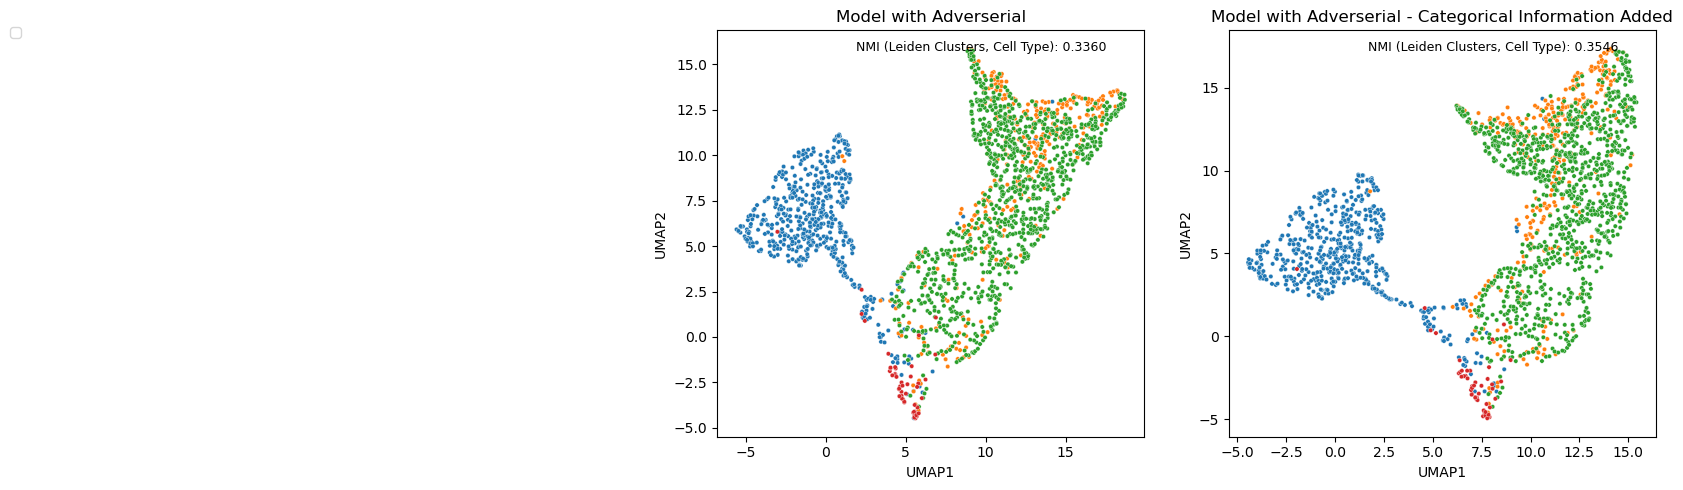

In [33]:
counterfactual_type = 'opposite'
bias_global_na, bias_global, bias_tot, _ = biases_clustered[counterfactual_type]
adata_types = ['Model No Adverserial', 'Model with Adverserial', 'Model with Adverserial - Categorical Information Added']
adata_dict = dict(zip(adata_types, 
                     [bias_global_na, bias_global,bias_tot]))


fig, ax = plt.subplots(ncols = 3, figsize = (15,5))
ax = ax.flatten()

subset_size = None
for i, (adata_type, adata) in enumerate(adata_dict.items()):
    if adata is not None:
        viz_df, nmi = adata_dimviz_bias(adata = adata, reduction_type = 'umap', cat = 'seurat_annotations', 
                             subset_size = subset_size)
        

        sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'seurat_annotations', 
                        s=10,
                        ax = ax[i])
        ax[i].annotate('NMI (Leiden Clusters, Cell Type): {:.4f}'.format(nmi),
                        xy = (0.325, 0.95), xycoords='axes fraction', fontsize = 9)
        ax[i].set_title(adata_type)
    else:
        ax[i].axis('off')

lines, labels = ax[0].get_legend_handles_labels()
fig.legend(lines, labels, loc="upper left", bbox_to_anchor=(-0.125, 0.95))
for ax_ in ax:
    ax_.legend().remove()
fig.tight_layout()
;

# Predictions

In [8]:
from Kang_utils import get_prediction, prepare_for_metrics, get_best_hyperparams, adata_dimviz_bias 

In [9]:
trainer = io.read_pickled_object(os.path.join(data_path, 'trash', 'Kang_fullbest_trainer.pickle'))
mod = trainer.mod

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()
test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())
train_cells_all = [barcode for barcode in tf_adata.obs_names if barcode not in test_cells]

cf_map = {'in_distribution': train_cells_all}
counterfactual_types = list(cf_map.keys()) + ['opposite']

counterfactual_types = ['opposite']

In [10]:
calculation_type = 'project' # project data rather than embed
n_neighbors = 15 # clustering as before
run_umap = True # also get the prediction umaps in addition to pca
best_resolution = tf_adata.uns['leiden']['params']['resolution']

In [17]:
counter = 0

tf_res = {}
loss_res = {}
for counterfactual_type in counterfactual_types:
    tf_res[counterfactual_type] = {}
    loss_res[counterfactual_type] = {}
    for remove_type in ['none', 'global_bias', 'categorical_bias', 'total_bias', 'adj']:
        print(counter)
        tf_adata_predicted, tot_loss = get_prediction(mod = mod, 
                                                      tf_adata = tf_adata, 
                                                      counterfactual_type = counterfactual_type, 
                                                      cf_map = cf_map, 
                                                      train_cells_all = train_cells_all, 
                                                      test_conds = test_conds, 
                                                      remove_type = remove_type,
                                                      return_bias = False, 
                                                      return_loss = False, 
                                                     test_cells = test_cells) 
        loss_res[counterfactual_type][remove_type] = tot_loss
        

            
        
        run_umap = True if remove_type == 'none' else False # for visualization
        tf_adata_predicted = prepare_for_metrics(tf_adata, 
                                                 tf_adata_predicted, 
                                                 resolution = best_resolution,
                                                 calculation_type = calculation_type, 
                                                 n_neighbors = n_neighbors, 
                                                 run_umap = run_umap
                                                )
        tf_res[counterfactual_type][remove_type] = tf_adata_predicted
        
        counter += 1
        

io.write_pickled_object(tf_res, 
                       os.path.join(data_path, 'trash', author + '_predictions.pickle'))
pd.DataFrame(loss_res).to_csv(os.path.join(data_path, 'trash', author + '_prediction_loss.csv'))


In [ ]:
loss_res = pd.read_csv(os.path.join(data_path, 'trash', author + '_prediction_loss.csv'), index_col = 0)